# Extreme precipitation: Changes under climate scenarios — Kazakhstan
# [Risk assessment]

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[HEAVY_RAINFALL](https://github.com/CLIMAAX/HEAVY_RAINFALL) GitHub repository.

## Data Substitutions

| Original (CLIMAAX / Europe) | Kazakhstan Replacement | Reason |
|---|---|---|
| EURO-CORDEX IDF via `pooch` / CLIMAAX cloud | ISIMIP3b-derived IDF from Hazard Assessment notebook | EURO-CORDEX covers Europe only |
| Rotated-pole coordinate lookup (`rlat`/`rlon`) | Standard `lat`/`lon` with `sel(method='nearest')` | ISIMIP3b uses regular WGS84 lat/lon |
| `IS_BIAS_CORRECTED` branch / KDTree lookup | Single lookup path (1-D lat/lon) | Not applicable to ISIMIP3b structure |
| `HAZARD_PATHS[duration][scenario]` | `HAZARD_PATHS[scenario]` | 24h only; no duration dimension in IDF files |
| Path A (pre-calculated European datasets via `pooch`) | Removed — Path B only | No global equivalent of CLIMAAX cloud storage |
| Regional threshold GeoTIFF (user-supplied) | Derived from historical IDF via per-pixel interpolation | No pre-existing Kazakhstan threshold dataset |
| GeoTIFF output (`rioxarray`/`rasterio`) | NetCDF output + cartopy/xarray plotting | Regular lat/lon grid; avoids rotated-pole raster complexity |
| Catalonia bounding box | Kazakhstan WGS84 bounding box | Geographic adaptation |

**Hazard input:** IDF NetCDFs produced by `EXTREME_PRECIPITATION_Hazard_Assessment_KZ.py`
(5-model mean, historical 1976–2005 and SSP1-2.6 / SSP3-7.0 2041–2070)

## Prepare your workspace

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import xarray as xr
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx

warnings.filterwarnings('ignore', category=RuntimeWarning)

### Configuration

In [ ]:
areaname = 'Kazakhstan'

TIME_FRAMES = {
    'historical': ('1976', '2005'),
    'ssp126':     ('2041', '2070'),
    'ssp370':     ('2041', '2070'),
}
hist_ystart, hist_yend = TIME_FRAMES['historical']

INTENSITY_TH = 50     
DURATION_TH  = 24     
FREQUENCY_TH = 10     


RETURN_PERIODS = np.asarray([2, 5, 10, 25, 50, 100, 200, 500])


POINT_LAT   = 43.25
POINT_LON   = 76.92
POINT_LABEL = 'Almaty'


SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)

HAZARD_RESULTS_DIR = Path('.') / f'results_{areaname}'

### Directory structure

In [3]:
workflow_dir = Path('.')
results_dir  = workflow_dir / f'results_risk_{areaname}'
plots_dir    = workflow_dir / f'plots_risk_{areaname}'

for d in [results_dir, plots_dir]:
    d.mkdir(parents=True, exist_ok=True)

print('Directory structure ready.')

Directory structure ready.


## Step 1: Load the hazard data

IDF files are read directly from the Hazard Assessment results directory.
Only the multi-model mean files are used here.

**Substitution note:** The original workflow supports two paths (pre-calculated
European dataset or locally computed). For Kazakhstan only the locally
computed path applies. The `IS_BIAS_CORRECTED` flag and `pooch` download
logic have been removed.

In [ ]:
def get_hazard_path(scenario):
    ystart, yend = TIME_FRAMES[scenario]
    fname = f'idf_24h_multimodel_{scenario}_{ystart}-{yend}.nc'
    p = HAZARD_RESULTS_DIR / fname
    if not p.exists():
        raise FileNotFoundError(
            f'Missing hazard file: {p}\n'
            'Run EXTREME_PRECIPITATION_Hazard_Assessment_KZ.py first.'
        )
    return p

HAZARD_PATHS = {scenario: get_hazard_path(scenario) for scenario in TIME_FRAMES}

print('Hazard files found:')
for scenario, p in HAZARD_PATHS.items():
    print(f'  {scenario}: {p.name}')

Hazard files found:
  historical: idf_24h_multimodel_historical_1976-2005.nc
  ssp126: idf_24h_multimodel_ssp126_2041-2070.nc
  ssp370: idf_24h_multimodel_ssp370_2041-2070.nc


### Explore the IDF data structure

In [5]:
ds_example = xr.open_dataset(HAZARD_PATHS['historical'])
print(ds_example)
print(f'\nReturn periods : {ds_example.return_period.values}')
print(f'Lat range      : {float(ds_example.lat.min()):.2f} – {float(ds_example.lat.max()):.2f}')
print(f'Lon range      : {float(ds_example.lon.min()):.2f} – {float(ds_example.lon.max()):.2f}')
ds_example.close()

<xarray.Dataset> Size: 160kB
Dimensions:        (return_period: 8, lat: 30, lon: 83)
Coordinates:
  * return_period  (return_period) int64 64B 2 5 10 25 50 100 200 500
  * lat            (lat) float64 240B 40.75 41.25 41.75 ... 54.25 54.75 55.25
  * lon            (lon) float64 664B 46.25 46.75 47.25 ... 86.25 86.75 87.25
Data variables:
    idf            (return_period, lat, lon) float64 159kB ...
Attributes:
    models:    GFDL-ESM4, IPSL-CM6A-LR, MPI-ESM1-2-HR, MRI-ESM2-0, UKESM1-0-LL
    scenario:  historical
    period:    1976-2005

Return periods : [  2   5  10  25  50 100 200 500]
Lat range      : 40.75 – 55.25
Lon range      : 46.25 – 87.25


## Step 2: Define the magnitude–frequency shift function

Unchanged from the original CLIMAAX workflow.
Given a critical threshold (intensity, duration, return period) and IDF
curves for a baseline and a future period, this function returns:
- The new return period if intensity is held fixed (frequency shift)
- The new intensity if return period is held fixed (magnitude shift)
- The precipitation scaling factor

In [ ]:
def magnitude_frequency_shift(th_int, th_freq, da_baseline, da_horizon):
    ret_per_bs   = da_baseline.return_period.values
    ret_per_proj = da_horizon.return_period.values
    prec_bs      = da_baseline.values
    prec_proj    = da_horizon.values

    prec_base_aux = np.interp(np.log(th_freq), np.log(ret_per_bs), prec_bs)

    shift_ret_per = np.interp(prec_base_aux, prec_proj, np.log(ret_per_proj))
    shift_ret_per = np.ceil(np.exp(shift_ret_per))

    prec_proj_aux = np.interp(np.log(th_freq), np.log(ret_per_proj), prec_proj)
    factor_prec   = prec_proj_aux / prec_base_aux
    shift_prec    = round(th_int * factor_prec, 2)
    factor_prec   = round(factor_prec, 2)

    return shift_ret_per, shift_prec, factor_prec

## Step 3: Site-specific risk assessment

Compute the magnitude and frequency shift at a single point.
Adjust `POINT_LAT`, `POINT_LON`, `POINT_LABEL`, `INTENSITY_TH`,
and `FREQUENCY_TH` in the Configuration cell above.

In [7]:
ds_hist_site = xr.open_dataset(HAZARD_PATHS['historical'])
ds_hist_site = ds_hist_site['idf'].sel(
    lat=POINT_LAT, lon=POINT_LON, method='nearest'
)

print(f'Site-specific assessment for {POINT_LABEL}')
print(f'  Nearest grid cell: lat={float(ds_hist_site.lat):.2f}, '
      f'lon={float(ds_hist_site.lon):.2f}\n')

for scenario in ['ssp126', 'ssp370']:
    ystart, yend = TIME_FRAMES[scenario]
    scen_label   = 'SSP1-2.6' if scenario == 'ssp126' else 'SSP3-7.0'

    ds_proj_site = xr.open_dataset(HAZARD_PATHS[scenario])
    ds_proj_site = ds_proj_site['idf'].sel(
        lat=POINT_LAT, lon=POINT_LON, method='nearest'
    )

    shift = magnitude_frequency_shift(
        INTENSITY_TH, FREQUENCY_TH, ds_hist_site, ds_proj_site
    )
    ds_proj_site.close()

    print(f'  {scen_label} ({ystart}–{yend}):')
    print(
        f'    Threshold: {INTENSITY_TH} mm/{DURATION_TH}h, '
        f'{FREQUENCY_TH}-year return period'
    )
    print(
        f'    → Fixed intensity: return period changes from '
        f'{FREQUENCY_TH} to {int(shift[0])} years'
    )
    print(
        f'    → Fixed return period: intensity changes by '
        f'{(shift[2]-1)*100:.1f}% '
        f'(from {INTENSITY_TH} to {shift[1]} mm/{DURATION_TH}h)'
    )
    print()

ds_hist_site.close()

Site-specific assessment for Almaty
  Nearest grid cell: lat=43.25, lon=76.75

  SSP1-2.6 (2041–2070):
    Threshold: 50 mm/24h, 10-year return period
    → Fixed intensity: return period changes from 10 to 7 years
    → Fixed return period: intensity changes by 8.0% (from 50 to 54.15 mm/24h)

  SSP3-7.0 (2041–2070):
    Threshold: 50 mm/24h, 10-year return period
    → Fixed intensity: return period changes from 10 to 9 years
    → Fixed return period: intensity changes by 4.0% (from 50 to 51.87 mm/24h)



## Step 4: Regional risk assessment

Apply `magnitude_frequency_shift` to every pixel over Kazakhstan.

**Regional threshold derivation (substitution note):**
The original workflow requires a user-supplied GeoTIFF showing the spatially
varying return period of the critical intensity. For Kazakhstan, no such file
exists, so the threshold return period is derived directly from the historical
IDF: for each pixel we interpolate what return period corresponds to
`INTENSITY_TH` mm/24h. This is scientifically equivalent — the GeoTIFF in
the original is itself derived from local IDF analysis.

Result: three NetCDF files per scenario saved in `results_risk_Kazakhstan/`:
- `RP_current_*`     : current return period of the threshold intensity
- `RP_shift_*`       : future return period at fixed intensity
- `PREC_factor_*`    : precipitation scaling factor at fixed return period

In [ ]:
def derive_threshold_rp(da_idf, intensity_th):
    ret_per_vals = da_idf.return_period.values
    log_rp       = np.log(ret_per_vals)
    idf_np       = da_idf.values   # (n_rp, n_lat, n_lon)
    n_rp, n_lat, n_lon = idf_np.shape
    rp_out       = np.full((n_lat, n_lon), np.nan)

    for i in range(n_lat):
        for j in range(n_lon):
            curve = idf_np[:, i, j]
            if np.any(np.isnan(curve)):
                continue
            if intensity_th < curve[0] or intensity_th > curve[-1]:
                continue
            rp_out[i, j] = np.exp(
                np.interp(intensity_th, curve, log_rp)
            )

    return xr.DataArray(
        rp_out,
        coords={'lat': da_idf.lat, 'lon': da_idf.lon},
        dims=['lat', 'lon'],
        attrs={
            'long_name': f'Return period of {intensity_th} mm/24h',
            'units': 'years',
        },
    )


def compute_regional_shift(scenario):
    ystart, yend = TIME_FRAMES[scenario]
    scen_label   = 'SSP1-2.6' if scenario == 'ssp126' else 'SSP3-7.0'

    out_rp_curr = results_dir / f'RP_current_{INTENSITY_TH}mm_{scenario}.nc'
    out_rp_shift = results_dir / (
        f'RP_shift_{INTENSITY_TH}mm_{scenario}_{ystart}-{yend}.nc'
    )
    out_prec_factor = results_dir / (
        f'PREC_factor_{INTENSITY_TH}mm_{scenario}_{ystart}-{yend}.nc'
    )

    if out_rp_curr.exists() and out_rp_shift.exists() and out_prec_factor.exists():
        print(f'  Cached: {scenario}')
        return {
            'rp_current':  out_rp_curr,
            'rp_shift':    out_rp_shift,
            'prec_factor': out_prec_factor,
        }

    print(f'  Computing regional shift for {scen_label} ({ystart}–{yend})...')

    ds_hist = xr.open_dataset(HAZARD_PATHS['historical'])
    ds_proj = xr.open_dataset(HAZARD_PATHS[scenario])
    da_hist = ds_hist['idf']   # (return_period, lat, lon)
    da_proj = ds_proj['idf']

    lat_vals = da_hist.lat.values
    lon_vals = da_hist.lon.values
    n_rp, n_lat, n_lon = da_hist.shape
    log_rp_vals = np.log(RETURN_PERIODS)

    print('    Deriving threshold return periods from historical IDF...')
    da_rp_current = derive_threshold_rp(da_hist, INTENSITY_TH)

    rp_shift_arr    = np.full((n_lat, n_lon), np.nan)
    prec_factor_arr = np.full((n_lat, n_lon), np.nan)

    hist_np = da_hist.values   
    proj_np = da_proj.values

    print(f'    Applying shift function to {n_lat * n_lon} pixels...')
    for i in range(n_lat):
        for j in range(n_lon):
            curve_h = hist_np[:, i, j]
            curve_p = proj_np[:, i, j]
            th_rp_ij = float(da_rp_current.values[i, j])

            if np.isnan(th_rp_ij) or np.any(np.isnan(curve_h)) or np.any(np.isnan(curve_p)):
                continue
            try:
                shift = magnitude_frequency_shift(
                    INTENSITY_TH, th_rp_ij,
                    xr.DataArray(curve_h, coords=[RETURN_PERIODS], dims=['return_period']),
                    xr.DataArray(curve_p, coords=[RETURN_PERIODS], dims=['return_period']),
                )
                rp_shift_arr[i, j]    = shift[0]
                prec_factor_arr[i, j] = shift[2]
            except Exception:
                continue

    coords = {'lat': lat_vals, 'lon': lon_vals}

    da_rp_current.to_netcdf(out_rp_curr)

    xr.DataArray(
        rp_shift_arr, coords=coords, dims=['lat', 'lon'],
        attrs={
            'long_name': (
                f'Future return period of {INTENSITY_TH} mm/24h '
                f'under {scen_label} {ystart}–{yend}'
            ),
            'units': 'years',
        },
    ).to_netcdf(out_rp_shift)

    xr.DataArray(
        prec_factor_arr, coords=coords, dims=['lat', 'lon'],
        attrs={
            'long_name': (
                f'Precipitation scaling factor at fixed RP '
                f'under {scen_label} {ystart}–{yend}'
            ),
            'units': '1',
        },
    ).to_netcdf(out_prec_factor)

    ds_hist.close()
    ds_proj.close()
    print(f'    Saved 3 files for {scenario}.')
    return {
        'rp_current':  out_rp_curr,
        'rp_shift':    out_rp_shift,
        'prec_factor': out_prec_factor,
    }


print('Computing regional risk assessment...\n')
REGIONAL_PATHS = {}
for scenario in ['ssp126', 'ssp370']:
    REGIONAL_PATHS[scenario] = compute_regional_shift(scenario)
print('\nDone.')

Computing regional risk assessment...

  Computing regional shift for SSP1-2.6 (2041–2070)...
    Deriving threshold return periods from historical IDF...
    Applying shift function to 2490 pixels...
    Saved 3 files for ssp126.
  Computing regional shift for SSP3-7.0 (2041–2070)...
    Deriving threshold return periods from historical IDF...
    Applying shift function to 2490 pixels...
    Saved 3 files for ssp370.

Done.


## Step 5: Visualise results

### 5.1 Site-specific frequency curve

IDF curves at the example site for historical baseline and both SSP scenarios,
with the critical threshold marked.

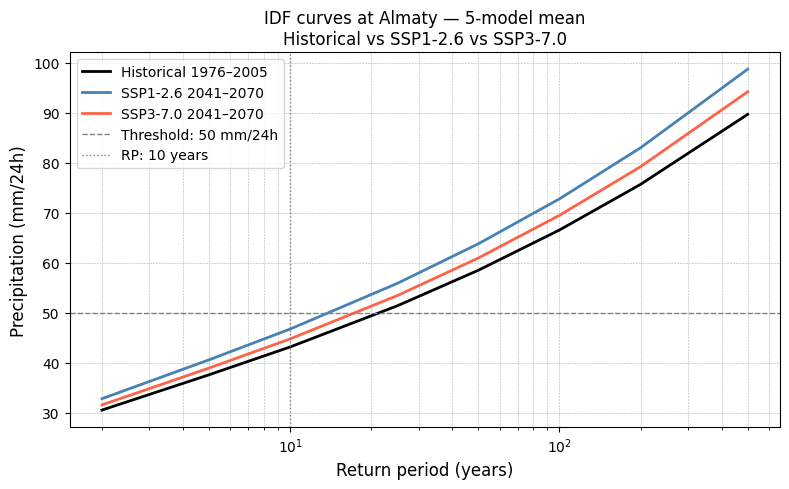

Saved: idf_site_Almaty.png


In [ ]:
fig_site, ax_site = plt.subplots(figsize=(8, 5))

colors = {'historical': 'black', 'ssp126': 'steelblue', 'ssp370': 'tomato'}
labels = {
    'historical': f'Historical {hist_ystart}–{hist_yend}',
    'ssp126':     'SSP1-2.6 2041–2070',
    'ssp370':     'SSP3-7.0 2041–2070',
}

for scenario in ['historical', 'ssp126', 'ssp370']:
    ds_s = xr.open_dataset(HAZARD_PATHS[scenario])
    da_s = ds_s['idf'].sel(lat=POINT_LAT, lon=POINT_LON, method='nearest')
    ax_site.plot(
        da_s.return_period.values, da_s.values,
        color=colors[scenario], linewidth=2, label=labels[scenario],
    )
    ds_s.close()

ax_site.axhline(INTENSITY_TH, color='gray', linestyle='--', linewidth=1,
                label=f'Threshold: {INTENSITY_TH} mm/24h')
ax_site.axvline(FREQUENCY_TH, color='gray', linestyle=':',  linewidth=1,
                label=f'RP: {FREQUENCY_TH} years')

ax_site.set_xscale('log')
ax_site.set_xlabel('Return period (years)', fontsize=12)
ax_site.set_ylabel('Precipitation (mm/24h)', fontsize=12)
ax_site.set_title(
    f'IDF curves at {POINT_LABEL} — 5-model mean\n'
    f'Historical vs SSP1-2.6 vs SSP3-7.0',
    fontsize=12,
)
ax_site.legend(fontsize=10)
ax_site.grid(True, which='both', linestyle='--', linewidth=0.4)
plt.tight_layout()
fig_site.savefig(plots_dir / f'idf_site_{POINT_LABEL}.png', dpi=150)
plt.show()
print(f'Saved: idf_site_{POINT_LABEL}.png')

### 5.2 Regional maps — return period shift and magnitude change

For each SSP scenario: current return period of the threshold intensity
(left) and future return period (right). A second figure shows the
precipitation scaling factor (%).

Saved: RP_shift_50mm_ssp126.png


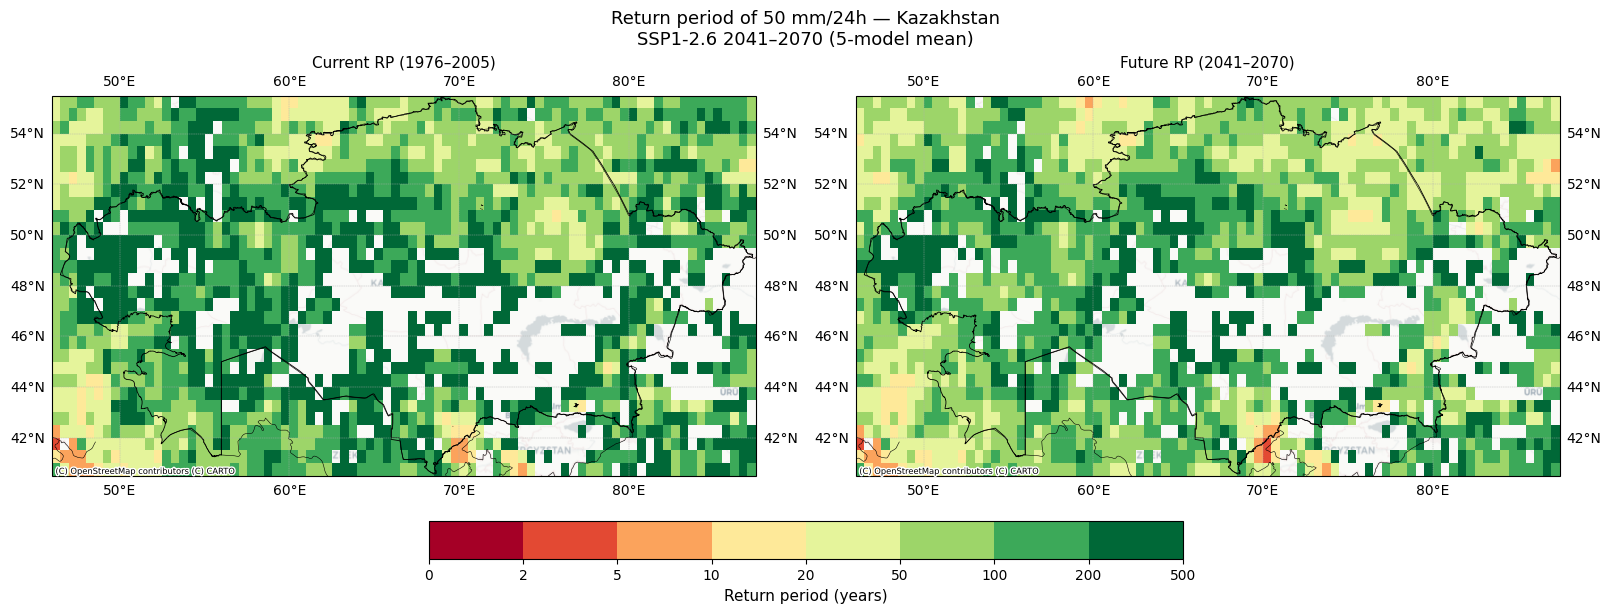

Saved: PREC_factor_50mm_ssp126.png


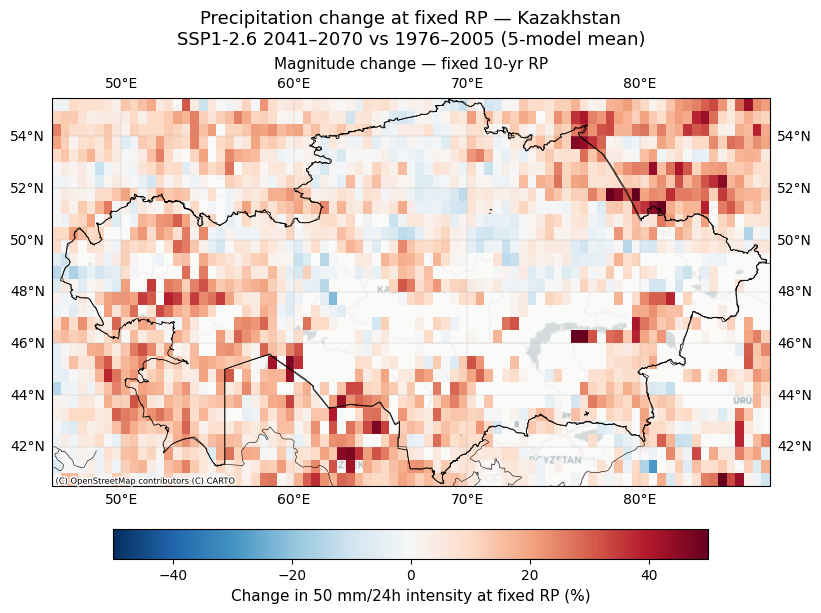

Saved: RP_shift_50mm_ssp370.png


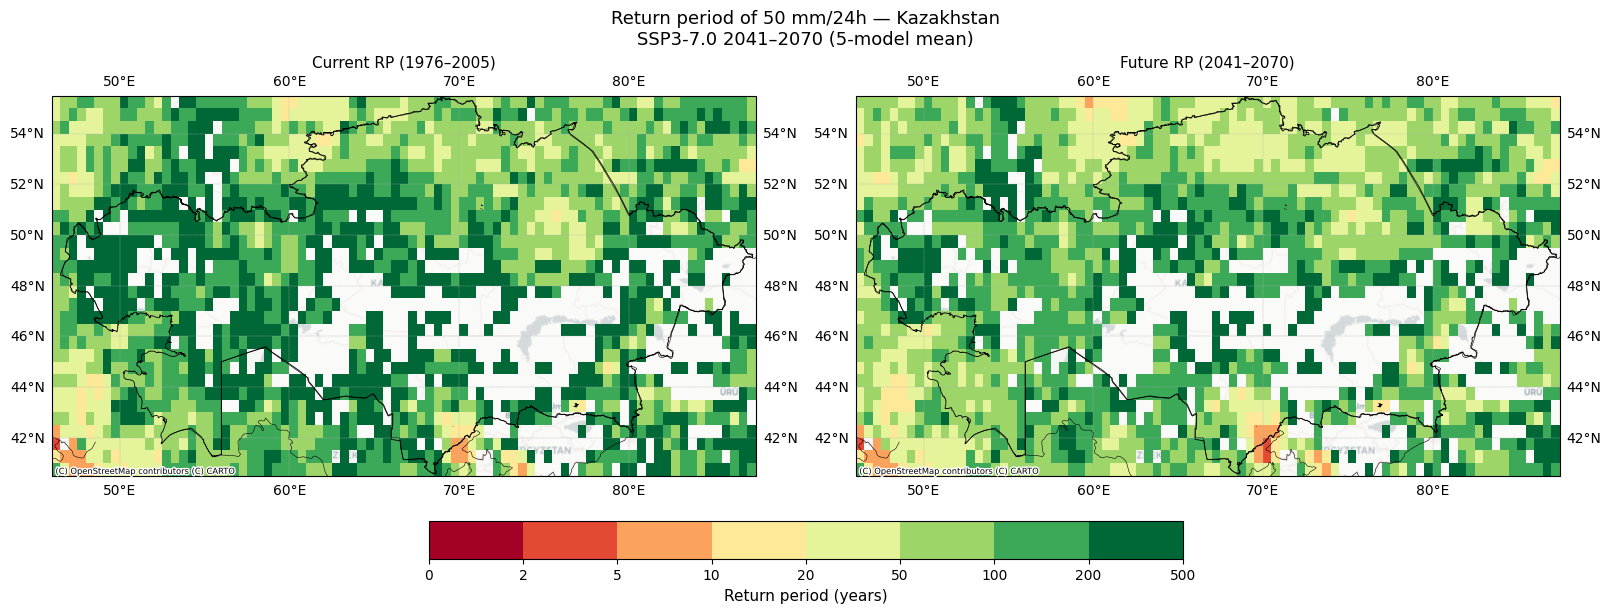

Saved: PREC_factor_50mm_ssp370.png


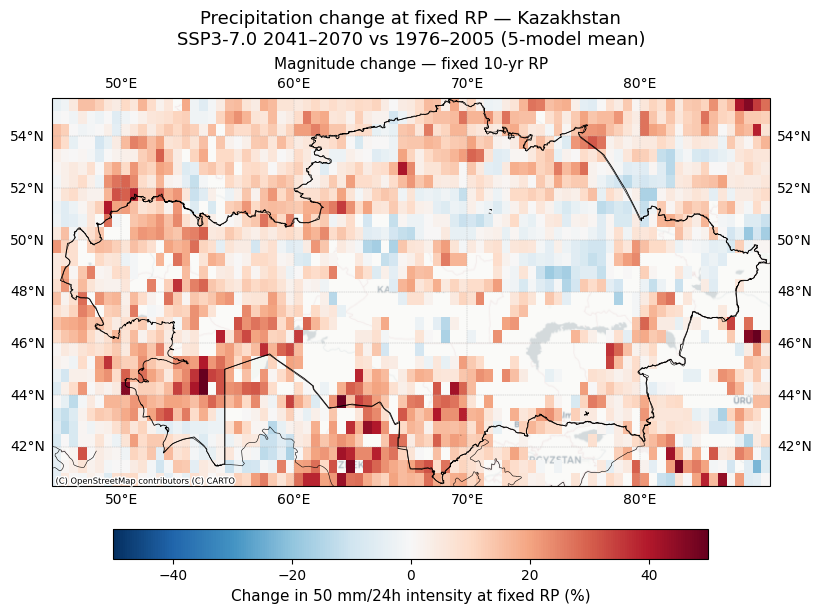

In [ ]:
kaz_gdf      = gpd.read_file(SHAPEFILE_PATH)
kaz_boundary = kaz_gdf.dissolve()

cmap_rp    = plt.get_cmap('RdYlGn')
bounds_rp  = [0, 2, 5, 10, 20, 50, 100, 200, 500]
norm_rp    = mpl.colors.BoundaryNorm(bounds_rp, cmap_rp.N)

for scenario in ['ssp126', 'ssp370']:
    ystart, yend = TIME_FRAMES[scenario]
    scen_label   = 'SSP1-2.6' if scenario == 'ssp126' else 'SSP3-7.0'
    paths        = REGIONAL_PATHS[scenario]

    da_rp_curr  = xr.open_dataarray(paths['rp_current'])
    da_rp_shift = xr.open_dataarray(paths['rp_shift'])
    da_factor   = xr.open_dataarray(paths['prec_factor'])

    fig1, axs1 = plt.subplots(
        1, 2, figsize=(16, 6),
        subplot_kw={'projection': ccrs.PlateCarree()},
        constrained_layout=True,
    )
    fig1.suptitle(
        f'Return period of {INTENSITY_TH} mm/24h — {areaname}\n'
        f'{scen_label} 2041–2070 (5-model mean)',
        fontsize=13,
    )

    for ax, da, title in zip(
        axs1,
        [da_rp_curr, da_rp_shift],
        [f'Current RP ({hist_ystart}–{hist_yend})',
         f'Future RP ({ystart}–{yend})'],
    ):
        im = da.plot(
            ax=ax, norm=norm_rp, cmap=cmap_rp,
            add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        kaz_boundary.boundary.plot(
            ax=ax, color='black', linewidth=0.6,
            transform=ccrs.PlateCarree(),
        )
        ax.set_title(title, fontsize=11)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--')
        ctx.add_basemap(
            ax=ax, crs='EPSG:4326',
            source=ctx.providers.CartoDB.Positron,
            attribution_size=6,
        )

    cb1 = fig1.colorbar(im, ax=axs1[:], ticks=bounds_rp,
                        orientation='horizontal', shrink=0.5)
    cb1.set_label('Return period (years)', fontsize=11)

    out1 = plots_dir / f'RP_shift_{INTENSITY_TH}mm_{scenario}.png'
    fig1.savefig(out1, dpi=150, bbox_inches='tight')
    print(f'Saved: {out1.name}')
    plt.show()

    fig2, ax2 = plt.subplots(
        figsize=(10, 6),
        subplot_kw={'projection': ccrs.PlateCarree()},
        constrained_layout=True,
    )
    fig2.suptitle(
        f'Precipitation change at fixed RP — {areaname}\n'
        f'{scen_label} 2041–2070 vs {hist_ystart}–{hist_yend} (5-model mean)',
        fontsize=13,
    )

    da_pct = (da_factor - 1) * 100
    im2 = da_pct.plot(
        ax=ax2, cmap='RdBu_r', vmin=-50, vmax=50,
        add_colorbar=False, transform=ccrs.PlateCarree(),
    )
    kaz_boundary.boundary.plot(
        ax=ax2, color='black', linewidth=0.6,
        transform=ccrs.PlateCarree(),
    )
    cb2 = fig2.colorbar(im2, ax=ax2, orientation='horizontal', shrink=0.6)
    cb2.set_label(
        f'Change in {INTENSITY_TH} mm/24h intensity at fixed RP (%)',
        fontsize=11,
    )
    ax2.set_title(
        f'Magnitude change — fixed {FREQUENCY_TH}-yr RP', fontsize=11
    )
    ax2.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax2.gridlines(draw_labels=True, linewidth=0.3, linestyle='--')
    ctx.add_basemap(
        ax=ax2, crs='EPSG:4326',
        source=ctx.providers.CartoDB.Positron,
        attribution_size=6,
    )

    out2 = plots_dir / f'PREC_factor_{INTENSITY_TH}mm_{scenario}.png'
    fig2.savefig(out2, dpi=150, bbox_inches='tight')
    print(f'Saved: {out2.name}')
    plt.show()

    da_rp_curr.close()
    da_rp_shift.close()
    da_factor.close()

## Kazakhstan-specific interpretation notes

- **Threshold choice:** The default 50 mm/24h is a indicative flash-flood
  warning level. Replace it with thresholds from Kazhydromet or municipal
  drainage design standards for your specific city or region.
- **Resolution caveat:** ISIMIP3b at 0.5° (~55 km) cannot resolve
  convective events. The return period maps show large-scale climate
  signals — point-scale extremes will be underestimated, especially
  in the Tian Shan and Altai foothills.
- **Dry pixel artefacts:** In very arid pixels (western/southern Kazakhstan)
  where `INTENSITY_TH` exceeds the 500-year return level in the historical
  IDF, `derive_threshold_rp` returns NaN. These appear as blank pixels in
  the maps and are scientifically correct — the threshold is effectively
  never reached at that resolution.
- **Multi-model spread:** These results use the 5-model mean. Load
  per-model IDF files from `results_Kazakhstan/idf_24h_{model}_*.nc`
  to examine uncertainty across models.
- **Sub-daily events:** Flash floods driven by convective cells lasting
  1–3 hours cannot be assessed from daily data. For infrastructure
  design (culverts, urban drainage), supplement with ERA5 hourly data
  for the historical period.

---
## Authors
Adapted for Kazakhstan by Ramazan Dauletov.
Original workflow by CRAHI-UPC (Meléndez-Landaverde et al.) for CLIMAAX.

## References
- Chow, V.T., Maidment, D.R., Mays, L.W. (1988). *Applied Hydrology*. McGraw-Hill.
- Fisher, R.A., Tippett, L.H.C. (1928). Limiting forms of the frequency distribution.
  *Math. Proc. Cambridge Phil. Soc.* 24(2), 180–190.
- Lange, S. (2019). Trend-preserving bias adjustment and statistical downscaling
  with ISIMIP3BASD. *Geosci. Model Dev.* 12, 3055–3070.